# AnemiaFusionNet — Phase 4: Multimodal Transformer Fusion

**Project:** AI-Powered Multimodal Anemia Detection System  
**Phase:** 4 of 5 — Transformer-Based Feature Fusion & Classification  
**Goal:** Fuse image (1280-d), clinical (64-d), and geo (64-d) feature vectors
via a Transformer Encoder and produce a final anemia probability

---

| # | Section | Description |
|---|---------|-------------|
| 1 | Setup & Imports | Libraries, seeds, device |
| 2 | Projection Layers | Map all modalities → 128-d common space |
| 3 | Token Generation | Stack projected vectors → (B, 3, 128) |
| 4 | Transformer Encoder | Cross-modal self-attention |
| 5 | Flatten | (B, 3, 128) → (B, 384) |
| 6 | Classification Head | 384 → 256 → 64 → 1 → sigmoid |
| 7 | MultiModalTransformer | Complete `nn.Module` class |
| 8 | Model Test | Dummy forward pass + shape checks |
| 9 | Save Model | `MODELS_DIR/multimodal_transformer.pth` |
| 10 | Architecture Diagram | `OUTPUTS_DIR/phase4_transformer_architecture.png` |
| 11 | Summary Report | Completion checklist |


---
## Section 1 — Setup & Imports

Import all required libraries, fix random seeds for reproducibility,
and configure the compute device (GPU if available, else CPU).


In [1]:
# =============================================================================
#  1.1  Library imports
# =============================================================================
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

import torch
import torch.nn as nn
import torchvision  # available for downstream use (e.g. loading Phase 3 backbone)

# =============================================================================
#  1.2  Reproducibility — fix all random seeds
# =============================================================================
SEED = 42

def set_seed(seed: int) -> None:
    """Pin seeds across Python / NumPy / PyTorch for deterministic results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# =============================================================================
#  1.3  Device configuration
# =============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {str(DEVICE).upper()}")
print(f"Random seed : {SEED}")
print(f"PyTorch     : {torch.__version__}")

from pathlib import Path
import os

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "dataset").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "dataset").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Project root not found. Make sure the project contains a 'dataset' folder."
    )

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGE_DIR = DATASET_DIR / "images"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

for folder in [
    PROCESSED_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project Root : {PROJECT_ROOT}")


Using device: CPU
Random seed : 42
PyTorch     : 2.12.1+cpu
Project Root : C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet


---
## Section 2 — Projection Layers

Each modality produces a feature vector of a different dimension:

| Modality | Source Model | Raw Dim |
|----------|-------------|---------|
| Image | EfficientNet-B0 | 1280 |
| Clinical | MLP Extractor | 64 |
| Geo Risk | GeoNet | 64 |

Before the Transformer can attend across modalities, **all vectors must share
the same dimension**. A single linear projection layer per modality maps each
into a common **128-dimensional latent space** — no activation is applied here
so the Transformer receives unconstrained representations.


In [2]:
# =============================================================================
#  2.1  Modality dimensions (constants — match Phase 3 outputs exactly)
# =============================================================================
IMAGE_DIM    = 1280   # EfficientNet-B0 feature vector
CLINICAL_DIM = 64     # MLP clinical extractor output
GEO_DIM      = 64     # GeoRisk extractor output
LATENT_DIM   = 128    # common projection dimension for all modalities

# =============================================================================
#  2.2  Stand-alone projection layers (for illustration)
#       These are also defined inside MultiModalTransformer in Section 7.
# =============================================================================
image_projection    = nn.Linear(IMAGE_DIM,    LATENT_DIM)   # 1280 → 128
clinical_projection = nn.Linear(CLINICAL_DIM, LATENT_DIM)   # 64   → 128
geo_projection      = nn.Linear(GEO_DIM,      LATENT_DIM)   # 64   → 128

print("Projection Layers:")
print(f"  image_projection    : nn.Linear({IMAGE_DIM:>4}, {LATENT_DIM})  "
      f"— params: {IMAGE_DIM * LATENT_DIM + LATENT_DIM:,}")
print(f"  clinical_projection : nn.Linear({CLINICAL_DIM:>4}, {LATENT_DIM})  "
      f"— params: {CLINICAL_DIM * LATENT_DIM + LATENT_DIM:,}")
print(f"  geo_projection      : nn.Linear({GEO_DIM:>4}, {LATENT_DIM})  "
      f"— params: {GEO_DIM * LATENT_DIM + LATENT_DIM:,}")
print(f"\n  All modalities projected → {LATENT_DIM}-dimensional space ✓")


Projection Layers:
  image_projection    : nn.Linear(1280, 128)  — params: 163,968
  clinical_projection : nn.Linear(  64, 128)  — params: 8,320
  geo_projection      : nn.Linear(  64, 128)  — params: 8,320

  All modalities projected → 128-dimensional space ✓


---
## Section 3 — Token Generation

After projection each feature vector becomes a **token** — a 128-dimensional
row that the Transformer will attend over. The three tokens are stacked along
a new sequence dimension (dim=1) to form the input tensor:

```
image_token    : (B, 128)  ─┐
clinical_token : (B, 128)   ├─ torch.stack(dim=1) ──► tokens : (B, 3, 128)
geo_token      : (B, 128)  ─┘
```

`B = batch size`, `3 = number of modalities`, `128 = latent dimension`


In [3]:
# =============================================================================
#  3.1  Token generation — demonstrated with a batch of 4 dummy samples
# =============================================================================
BATCH_SIZE = 4

# Dummy feature vectors (simulate Phase 3 extractor outputs)
dummy_image_feat    = torch.randn(BATCH_SIZE, IMAGE_DIM)
dummy_clinical_feat = torch.randn(BATCH_SIZE, CLINICAL_DIM)
dummy_geo_feat      = torch.randn(BATCH_SIZE, GEO_DIM)

# Project each modality into the shared latent space
image_token    = image_projection(dummy_image_feat)       # (4, 128)
clinical_token = clinical_projection(dummy_clinical_feat) # (4, 128)
geo_token      = geo_projection(dummy_geo_feat)           # (4, 128)

# Stack along sequence dimension → (Batch, 3, 128)
tokens = torch.stack([image_token, clinical_token, geo_token], dim=1)

print(f"  image_token    shape : {tuple(image_token.shape)}")
print(f"  clinical_token shape : {tuple(clinical_token.shape)}")
print(f"  geo_token      shape : {tuple(geo_token.shape)}")
print()
print(f"Token Shape : {tuple(tokens.shape)}")
print(f"  Interpretation → (Batch={BATCH_SIZE}, Sequence=3 modalities, Dim={LATENT_DIM})")


  image_token    shape : (4, 128)
  clinical_token shape : (4, 128)
  geo_token      shape : (4, 128)

Token Shape : (4, 3, 128)
  Interpretation → (Batch=4, Sequence=3 modalities, Dim=128)


---
## Section 4 — Transformer Encoder

The Transformer Encoder applies **multi-head self-attention** across the three
modality tokens, allowing each modality to attend to — and be influenced by —
the other two. This is where cross-modal information is exchanged.

**Configuration:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `d_model` | 128 | Matches projection output |
| `nhead` | 4 | 128 / 4 = 32-dim per head |
| `num_layers` | 2 | Sufficient depth for 3-token sequences |
| `dim_feedforward` | 256 | 2× d_model (standard ratio) |
| `dropout` | 0.1 | Light regularisation |
| `batch_first` | True | Input shape (B, S, D) — PyTorch convention |


In [4]:
# =============================================================================
#  4.1  Transformer Encoder configuration
# =============================================================================
EMBED_DIM       = 128   # must equal LATENT_DIM
NUM_HEADS       = 4     # EMBED_DIM must be divisible by NUM_HEADS
NUM_LAYERS      = 2
FFN_DIM         = 256   # feed-forward hidden size inside each encoder layer
DROPOUT         = 0.1

# =============================================================================
#  4.2  Build the encoder
# =============================================================================
encoder_layer = nn.TransformerEncoderLayer(
    d_model         = EMBED_DIM,
    nhead           = NUM_HEADS,
    dim_feedforward = FFN_DIM,
    dropout         = DROPOUT,
    batch_first     = True,     # (B, S, D) input convention
    activation      = "relu",
)

transformer_encoder = nn.TransformerEncoder(
    encoder_layer = encoder_layer,
    num_layers    = NUM_LAYERS,
)

# =============================================================================
#  4.3  Single forward pass through the encoder
# =============================================================================
transformer_output = transformer_encoder(tokens)  # input: (4, 3, 128)

print(f"  Transformer Input  shape : {tuple(tokens.shape)}")
print(f"  Transformer Output shape : {tuple(transformer_output.shape)}")
print()
print(f"  Encoder layers      : {NUM_LAYERS}")
print(f"  Attention heads     : {NUM_HEADS}")
print(f"  Head dimension      : {EMBED_DIM // NUM_HEADS}")
print(f"  Feed-forward dim    : {FFN_DIM}")
print(f"  Dropout             : {DROPOUT}")
print()
# Count encoder parameters
enc_params = sum(p.numel() for p in transformer_encoder.parameters())
print(f"  Encoder parameters  : {enc_params:,}")


  Transformer Input  shape : (4, 3, 128)
  Transformer Output shape : (4, 3, 128)

  Encoder layers      : 2
  Attention heads     : 4
  Head dimension      : 32
  Feed-forward dim    : 256
  Dropout             : 0.1

  Encoder parameters  : 264,960


---
## Section 5 — Flatten

After the Transformer processes all three tokens, each token has attended to
the others. We concatenate all tokens into a single vector before the
classifier. This preserves information from every modality in the final
representation.

```
(B, 3, 128)  ──► flatten(start_dim=1) ──►  (B, 384)
                                              └── 3 × 128 = 384
```


In [5]:
# =============================================================================
#  5.1  Flatten transformer output
# =============================================================================
fused_vector = transformer_output.flatten(start_dim=1)   # (4, 3*128) = (4, 384)

FUSED_DIM = EMBED_DIM * 3   # 384

print(f"  Transformer Output : {tuple(transformer_output.shape)}")
print(f"  After Flatten      : {tuple(fused_vector.shape)}")
print()
print(f"Flatten Shape : {tuple(fused_vector.shape)}")
print(f"  Calculation  : {NUM_HEADS * (EMBED_DIM // NUM_HEADS)} (embed) × 3 (tokens) = {FUSED_DIM}")


  Transformer Output : (4, 3, 128)
  After Flatten      : (4, 384)

Flatten Shape : (4, 384)
  Calculation  : 128 (embed) × 3 (tokens) = 384


---
## Section 6 — Classification Head

The classification head maps the fused 384-dimensional representation to a
**single scalar probability** using a progressively narrowing MLP:

```
384 → Linear(256) → ReLU → Dropout(0.3)
    → Linear(64)  → ReLU
    → Linear(1)   → Sigmoid  →  P(Anemia)
```

`Sigmoid` squashes the output to `[0, 1]`, interpretable as the probability
that the patient is anemic (threshold 0.5 for binary classification).


In [6]:
# =============================================================================
#  6.1  Classification head
# =============================================================================
classifier_head = nn.Sequential(
    nn.Linear(FUSED_DIM, 256),   # 384 → 256
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),

    nn.Linear(256, 64),          # 256 → 64
    nn.ReLU(inplace=True),

    nn.Linear(64, 1),            # 64  → 1  (logit)
    nn.Sigmoid(),                # 1   → probability ∈ [0, 1]
)

# Test the head on the fused vector
prediction = classifier_head(fused_vector)   # (4, 1)

cls_params = sum(p.numel() for p in classifier_head.parameters())

print(f"  Input  (fused vector) : {tuple(fused_vector.shape)}")
print(f"  Output (probability)  : {tuple(prediction.shape)}")
print(f"  Classifier parameters : {cls_params:,}")
print()
print("  Sample predictions (batch of 4):")
for i, p in enumerate(prediction.detach().numpy()):
    label = "Anemic" if p[0] >= 0.5 else "Non-Anemic"
    print(f"    Patient {i+1} :  P(Anemia) = {p[0]:.4f}  →  {label}")


  Input  (fused vector) : (4, 384)
  Output (probability)  : (4, 1)
  Classifier parameters : 115,073

  Sample predictions (batch of 4):
    Patient 1 :  P(Anemia) = 0.4684  →  Non-Anemic
    Patient 2 :  P(Anemia) = 0.4232  →  Non-Anemic
    Patient 3 :  P(Anemia) = 0.4130  →  Non-Anemic
    Patient 4 :  P(Anemia) = 0.4850  →  Non-Anemic


---
## Section 7 — Complete Fusion Network: `MultiModalTransformer`

All components (projection layers, Transformer encoder, flatten, classifier)
are encapsulated in a single `nn.Module` for clean training and deployment.

**Design principles:**
- Each submodule is named clearly for easy `state_dict` inspection
- `forward()` accepts the three raw feature vectors as separate arguments
- The class is self-contained — no external projection layer objects needed


In [7]:
# =============================================================================
#  7.1  MultiModalTransformer — complete nn.Module
# =============================================================================

class MultiModalTransformer(nn.Module):
    """
    Transformer-based multimodal fusion network for anemia detection.

    Takes three independently extracted feature vectors (image, clinical, geo),
    projects them into a shared latent space, fuses them via a Transformer
    Encoder, and predicts the probability of anemia.

    Architecture:
        image (1280) ──┐
        clinical (64) ─┼─► Projection (→128 each) ─► Stack (B,3,128)
        geo (64) ──────┘
                            │
                    TransformerEncoder (2 layers, 4 heads)
                            │
                       Flatten (B,384)
                            │
                    Classifier (384→256→64→1)
                            │
                    Sigmoid → P(Anemia) ∈ [0,1]

    Args:
        image_dim    (int)  : Image feature dimension.    Default 1280.
        clinical_dim (int)  : Clinical feature dimension. Default 64.
        geo_dim      (int)  : Geo feature dimension.      Default 64.
        latent_dim   (int)  : Shared projection dim.      Default 128.
        num_heads    (int)  : Transformer attention heads. Default 4.
        num_layers   (int)  : Transformer encoder layers. Default 2.
        ffn_dim      (int)  : Feedforward hidden size.    Default 256.
        dropout      (float): Dropout probability.        Default 0.1.
    """

    def __init__(
        self,
        image_dim    : int   = 1280,
        clinical_dim : int   = 64,
        geo_dim      : int   = 64,
        latent_dim   : int   = 128,
        num_heads    : int   = 4,
        num_layers   : int   = 2,
        ffn_dim      : int   = 256,
        dropout      : float = 0.1,
    ):
        super(MultiModalTransformer, self).__init__()

        # Store hyperparameters for introspection
        self.latent_dim = latent_dim
        self.num_tokens = 3   # image, clinical, geo
        self.fused_dim  = latent_dim * self.num_tokens   # 384

        # ── Projection layers — map each modality to shared latent space ─────
        self.image_projection    = nn.Linear(image_dim,    latent_dim)
        self.clinical_projection = nn.Linear(clinical_dim, latent_dim)
        self.geo_projection      = nn.Linear(geo_dim,      latent_dim)

        # ── Transformer Encoder — cross-modal self-attention ──────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = latent_dim,
            nhead           = num_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            batch_first     = True,
            activation      = "relu",
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer = encoder_layer,
            num_layers    = num_layers,
        )

        # ── Classification head — fused representation → probability ──────────
        self.classifier = nn.Sequential(
            nn.Linear(self.fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

        # Weight initialisation
        self._init_weights()

    # ── Weight initialisation ────────────────────────────────────────────────
    def _init_weights(self) -> None:
        """Xavier uniform init for all Linear layers; zeros for biases."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    # ── Forward pass ─────────────────────────────────────────────────────────
    def forward(
        self,
        image_features    : torch.Tensor,   # (B, 1280)
        clinical_features : torch.Tensor,   # (B, 64)
        geo_features      : torch.Tensor,   # (B, 64)
    ) -> torch.Tensor:
        """
        Args:
            image_features    : Tensor (B, image_dim)
            clinical_features : Tensor (B, clinical_dim)
            geo_features      : Tensor (B, geo_dim)

        Returns:
            probability : Tensor (B, 1) — P(Anemia) in [0, 1]
        """
        # ── Step 1: Project to common latent dimension ────────────────────────
        img_token  = self.image_projection(image_features)       # (B, 128)
        clin_token = self.clinical_projection(clinical_features) # (B, 128)
        geo_token  = self.geo_projection(geo_features)           # (B, 128)

        # ── Step 2: Stack into token sequence ─────────────────────────────────
        tokens = torch.stack([img_token, clin_token, geo_token], dim=1)  # (B, 3, 128)

        # ── Step 3: Transformer Encoder — cross-modal attention ───────────────
        fused_tokens = self.transformer(tokens)                  # (B, 3, 128)

        # ── Step 4: Flatten all tokens into a single vector ───────────────────
        fused_vector = fused_tokens.flatten(start_dim=1)         # (B, 384)

        # ── Step 5: Classify → anemia probability ─────────────────────────────
        probability = self.classifier(fused_vector)              # (B, 1)

        return probability

    # ── Convenience: parameter count ─────────────────────────────────────────
    def count_parameters(self) -> dict:
        """Return total and per-submodule parameter counts."""
        def n(module): return sum(p.numel() for p in module.parameters())
        return {
            "image_projection"    : n(self.image_projection),
            "clinical_projection" : n(self.clinical_projection),
            "geo_projection"      : n(self.geo_projection),
            "transformer"         : n(self.transformer),
            "classifier"          : n(self.classifier),
            "total"               : n(self),
        }


# =============================================================================
#  7.2  Instantiate the model
# =============================================================================
model = MultiModalTransformer(
    image_dim    = IMAGE_DIM,
    clinical_dim = CLINICAL_DIM,
    geo_dim      = GEO_DIM,
    latent_dim   = LATENT_DIM,
    num_heads    = NUM_HEADS,
    num_layers   = NUM_LAYERS,
    ffn_dim      = FFN_DIM,
    dropout      = DROPOUT,
).to(DEVICE)

param_counts = model.count_parameters()

print("=" * 55)
print("  MultiModalTransformer — Built Successfully")
print("=" * 55)
print(f"  {'Submodule':<28} {'Parameters':>12}")
print(f"  {'-'*28} {'-'*12}")
for key, count in param_counts.items():
    marker = "─── TOTAL" if key == "total" else ""
    print(f"  {key:<28} {count:>12,}  {marker}")
print("=" * 55)


  MultiModalTransformer — Built Successfully
  Submodule                      Parameters
  ---------------------------- ------------
  image_projection                  163,968  
  clinical_projection                 8,320  
  geo_projection                      8,320  
  transformer                       264,960  
  classifier                        115,073  
  total                             560,641  ─── TOTAL


---
## Section 8 — Model Test: Full Forward Pass

Generate a batch of 4 dummy patients and run a complete forward pass through
`MultiModalTransformer`, printing the tensor shape at every intermediate step.


In [8]:
# =============================================================================
#  8.1  Dummy batch (batch_size = 4)
# =============================================================================
B = 4

image_batch    = torch.randn(B, IMAGE_DIM).to(DEVICE)     # (4, 1280)
clinical_batch = torch.randn(B, CLINICAL_DIM).to(DEVICE)  # (4, 64)
geo_batch      = torch.randn(B, GEO_DIM).to(DEVICE)       # (4, 64)

print("=" * 55)
print("  FORWARD PASS — Input Shapes")
print("=" * 55)
print(f"  Image Shape    : {tuple(image_batch.shape)}")
print(f"  Clinical Shape : {tuple(clinical_batch.shape)}")
print(f"  Geo Shape      : {tuple(geo_batch.shape)}")

# =============================================================================
#  8.2  Step-by-step forward pass with intermediate shape logging
# =============================================================================
model.eval()
with torch.no_grad():

    # Projection
    img_tok  = model.image_projection(image_batch)
    clin_tok = model.clinical_projection(clinical_batch)
    geo_tok  = model.geo_projection(geo_batch)

    # Token stacking
    token_tensor = torch.stack([img_tok, clin_tok, geo_tok], dim=1)

    # Transformer
    transformer_out = model.transformer(token_tensor)

    # Flatten
    flat = transformer_out.flatten(start_dim=1)

    # Classifier
    prediction = model.classifier(flat)

print()
print("=" * 55)
print("  FORWARD PASS — Intermediate Shapes")
print("=" * 55)
print(f"  image_projection output  : {tuple(img_tok.shape)}")
print(f"  clinical_projection out  : {tuple(clin_tok.shape)}")
print(f"  geo_projection output    : {tuple(geo_tok.shape)}")
print()
print(f"  Token Shape              : {tuple(token_tensor.shape)}")
print(f"  Transformer Output       : {tuple(transformer_out.shape)}")
print(f"  Flatten Shape            : {tuple(flat.shape)}")
print(f"  Prediction Shape         : {tuple(prediction.shape)}")
print()

# =============================================================================
#  8.3  Shape assertions
# =============================================================================
assert token_tensor.shape == (B, 3, LATENT_DIM), "Token shape mismatch"
assert transformer_out.shape == (B, 3, LATENT_DIM), "Transformer output shape mismatch"
assert flat.shape == (B, LATENT_DIM * 3), "Flatten shape mismatch"
assert prediction.shape == (B, 1), "Prediction shape mismatch"

print("  Sample predictions (batch of 4):")
for i, p in enumerate(prediction.cpu().numpy()):
    label = "Anemic" if p[0] >= 0.5 else "Non-Anemic"
    print(f"    Patient {i+1} :  P(Anemia) = {p[0]:.4f}  →  {label}")

print()
print("  All shape assertions passed ✅")
print("=" * 55)


  FORWARD PASS — Input Shapes
  Image Shape    : (4, 1280)
  Clinical Shape : (4, 64)
  Geo Shape      : (4, 64)

  FORWARD PASS — Intermediate Shapes
  image_projection output  : (4, 128)
  clinical_projection out  : (4, 128)
  geo_projection output    : (4, 128)

  Token Shape              : (4, 3, 128)
  Transformer Output       : (4, 3, 128)
  Flatten Shape            : (4, 384)
  Prediction Shape         : (4, 1)

  Sample predictions (batch of 4):
    Patient 1 :  P(Anemia) = 0.3298  →  Non-Anemic
    Patient 2 :  P(Anemia) = 0.5038  →  Anemic
    Patient 3 :  P(Anemia) = 0.5379  →  Anemic
    Patient 4 :  P(Anemia) = 0.6117  →  Anemic

  All shape assertions passed ✅


---
## Section 9 — Save Model

Save the model's `state_dict` alongside its hyperparameter configuration so
Phase 5 (training) can reload the exact architecture without hard-coding values.


In [9]:
# =============================================================================
#  9.1  Build and save checkpoint
# =============================================================================
MODEL_PATH = MODELS_DIR / "multimodal_transformer.pth"

checkpoint = {
    "state_dict": model.state_dict(),
    "config": {
        "image_dim"    : IMAGE_DIM,
        "clinical_dim" : CLINICAL_DIM,
        "geo_dim"      : GEO_DIM,
        "latent_dim"   : LATENT_DIM,
        "num_heads"    : NUM_HEADS,
        "num_layers"   : NUM_LAYERS,
        "ffn_dim"      : FFN_DIM,
        "dropout"      : DROPOUT,
    },
    "param_counts": param_counts,
}

torch.save(checkpoint, MODEL_PATH)

size_kb = MODEL_PATH.stat().st_size / 1024
print("=" * 55)
print("  MODEL CHECKPOINT SAVED")
print("=" * 55)
print(f"  Path       : {MODEL_PATH}")
print(f"  File size  : {size_kb:,.1f} KB")
print()
print("  Saved config:")
for k, v in checkpoint["config"].items():
    print(f"    {k:<18} : {v}")
print()

# =============================================================================
#  9.2  Reload and verify (smoke test)
# =============================================================================
loaded = torch.load(MODEL_PATH, map_location=DEVICE)
cfg    = loaded["config"]

verify_model = MultiModalTransformer(**cfg).to(DEVICE)
verify_model.load_state_dict(loaded["state_dict"])
verify_model.eval()

with torch.no_grad():
    test_out = verify_model(image_batch, clinical_batch, geo_batch)

assert test_out.shape == (B, 1), "Reload verification failed"
print(f"  Reload verification : ✅  output shape {tuple(test_out.shape)}")
print("=" * 55)


  MODEL CHECKPOINT SAVED
  Path       : C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\models\multimodal_transformer.pth
  File size  : 2,203.9 KB

  Saved config:
    image_dim          : 1280
    clinical_dim       : 64
    geo_dim            : 64
    latent_dim         : 128
    num_heads          : 4
    num_layers         : 2
    ffn_dim            : 256
    dropout            : 0.1

  Reload verification : ✅  output shape (4, 1)


---
## Section 10 — Architecture Diagram

A full matplotlib diagram of the Phase 4 fusion pipeline — from raw modality
feature vectors through projection, Transformer, flatten, and classifier to
the final anemia probability.


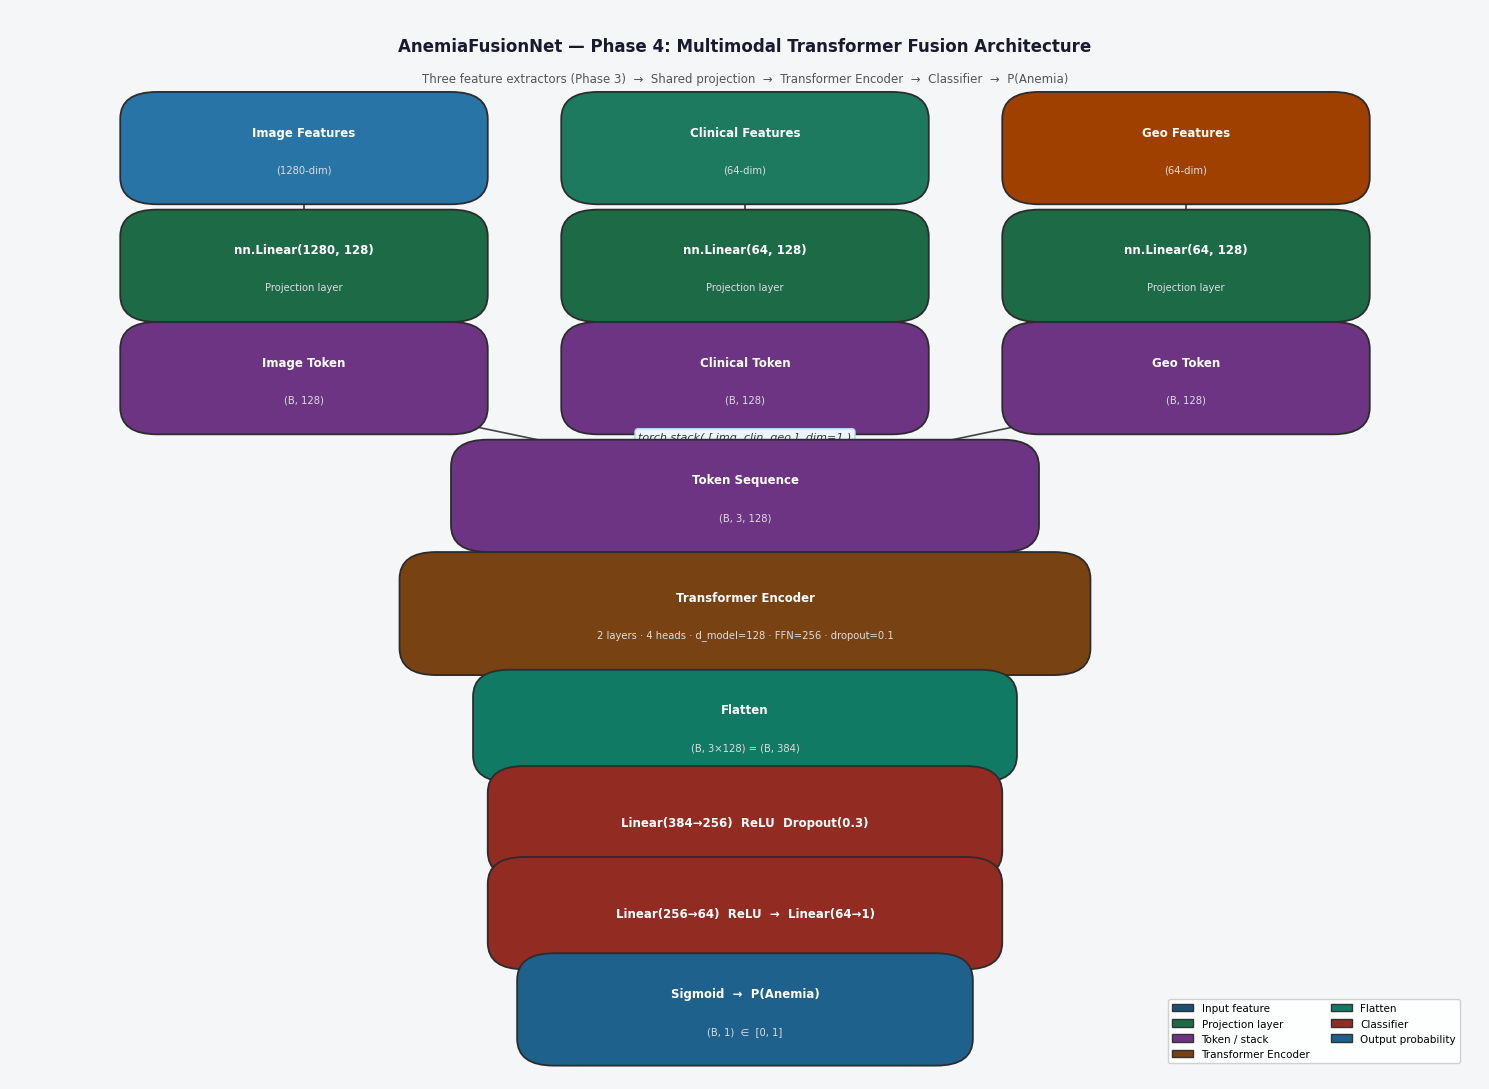

✅ Architecture diagram saved → C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\outputs\phase4_transformer_architecture.png


In [10]:
# =============================================================================
#  10.1  Architecture diagram
# =============================================================================

# ── Helpers ───────────────────────────────────────────────────────────────────
def rbox(ax, x, y, w, h, fc, text, sub="", ec="#2C2C2C", lw=1.3, r=0.025):
    """Draw a rounded rectangle with centred label and optional sub-label."""
    patch = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad={r}",
        facecolor=fc, edgecolor=ec, linewidth=lw, zorder=3,
    )
    ax.add_patch(patch)
    dy = 0.015 if sub else 0
    ax.text(x, y + dy, text,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color="white", zorder=4)
    if sub:
        ax.text(x, y - 0.02, sub,
                ha="center", va="center", fontsize=7.2,
                color="#DDDDDD", zorder=4)

def arrow_v(ax, x, y0, y1, color="#444"):
    """Vertical downward arrow from y0 to y1."""
    ax.annotate("", xy=(x, y1 + 0.012), xytext=(x, y0 - 0.012),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3), zorder=2)

def arrow_conv(ax, x_src, y_src, x_dst, y_dst, color="#444"):
    """Diagonal arrow from (x_src, y_src) to (x_dst, y_dst)."""
    ax.annotate("", xy=(x_dst, y_dst + 0.012), xytext=(x_src, y_src - 0.012),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                connectionstyle="arc3,rad=0.0", lw=1.2),
                zorder=2)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor("#F4F6F8")

# ── Colour palette ────────────────────────────────────────────────────────────
C = {
    "inp"    : "#1A5276",   # dark blue   — input features
    "proj"   : "#1D6A46",   # dark green  — projection
    "token"  : "#6C3483",   # purple      — tokens
    "trans"  : "#784212",   # amber-brown — transformer
    "flat"   : "#117A65",   # teal        — flatten
    "cls"    : "#922B21",   # red         — classifier
    "out"    : "#1F618D",   # medium blue — output
}

W = 0.20   # box width
H = 0.055  # box height

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(0.5, 0.965,
        "AnemiaFusionNet — Phase 4: Multimodal Transformer Fusion Architecture",
        ha="center", va="center", fontsize=12, fontweight="bold", color="#1A1A2E")
ax.text(0.5, 0.935,
        "Three feature extractors (Phase 3)  →  Shared projection  →  "
        "Transformer Encoder  →  Classifier  →  P(Anemia)",
        ha="center", va="center", fontsize=8.5, color="#555555")

# ── Three input columns ───────────────────────────────────────────────────────
cols = {
    "Image"    : (0.20, "#2874A6"),
    "Clinical" : (0.50, "#1D7A5F"),
    "Geo"      : (0.80, "#A04000"),
}
dims = {"Image": "1280", "Clinical": "64", "Geo": "64"}

# Row y-coordinates
Y = {
    "input"   : 0.870,
    "proj"    : 0.760,
    "token"   : 0.655,
    "stack"   : 0.545,
    "trans"   : 0.435,
    "flat"    : 0.330,
    "cls1"    : 0.240,
    "cls2"    : 0.155,
    "out"     : 0.065,
}

# ── Input boxes ───────────────────────────────────────────────────────────────
for name, (cx, col) in cols.items():
    rbox(ax, cx, Y["input"], W, H, col,
         f"{name} Features", f"({dims[name]}-dim)")

# ── Projection boxes ──────────────────────────────────────────────────────────
for name, (cx, _) in cols.items():
    arrow_v(ax, cx, Y["input"], Y["proj"])
    rbox(ax, cx, Y["proj"], W, H, C["proj"],
         f"nn.Linear({dims[name]}, 128)", "Projection layer")

# ── Token boxes ───────────────────────────────────────────────────────────────
for name, (cx, _) in cols.items():
    arrow_v(ax, cx, Y["proj"], Y["token"])
    rbox(ax, cx, Y["token"], W, H, C["token"],
         f"{name} Token", "(B, 128)")

# ── Stack label + convergence arrows ─────────────────────────────────────────
stack_cx = 0.50
ax.text(stack_cx, (Y["token"] + Y["stack"])/2,
        "torch.stack( [ img, clin, geo ], dim=1 )",
        ha="center", va="center", fontsize=8,
        color="#333", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#EBF5FB",
                  edgecolor="#AED6F1", linewidth=1))

for name, (cx, _) in cols.items():
    arrow_conv(ax, cx, Y["token"], stack_cx, Y["stack"])

rbox(ax, stack_cx, Y["stack"], 0.35, H, C["token"],
     "Token Sequence", "(B, 3, 128)")

# ── Transformer ───────────────────────────────────────────────────────────────
arrow_v(ax, stack_cx, Y["stack"], Y["trans"])
rbox(ax, stack_cx, Y["trans"], 0.42, H + 0.01, C["trans"],
     "Transformer Encoder",
     "2 layers · 4 heads · d_model=128 · FFN=256 · dropout=0.1")

# ── Flatten ───────────────────────────────────────────────────────────────────
arrow_v(ax, stack_cx, Y["trans"], Y["flat"])
rbox(ax, stack_cx, Y["flat"], 0.32, H, C["flat"],
     "Flatten", "(B, 3×128) = (B, 384)")

# ── Classifier ────────────────────────────────────────────────────────────────
arrow_v(ax, stack_cx, Y["flat"], Y["cls1"])
rbox(ax, stack_cx, Y["cls1"], 0.30, H, C["cls"],
     "Linear(384→256)  ReLU  Dropout(0.3)", "")

arrow_v(ax, stack_cx, Y["cls1"], Y["cls2"])
rbox(ax, stack_cx, Y["cls2"], 0.30, H, C["cls"],
     "Linear(256→64)  ReLU  →  Linear(64→1)", "")

# ── Output ────────────────────────────────────────────────────────────────────
arrow_v(ax, stack_cx, Y["cls2"], Y["out"])
rbox(ax, stack_cx, Y["out"], 0.26, H, C["out"],
     "Sigmoid  →  P(Anemia)", "(B, 1)  ∈  [0, 1]")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(fc=C["inp"],   ec="#333", label="Input feature"),
    mpatches.Patch(fc=C["proj"],  ec="#333", label="Projection layer"),
    mpatches.Patch(fc=C["token"], ec="#333", label="Token / stack"),
    mpatches.Patch(fc=C["trans"], ec="#333", label="Transformer Encoder"),
    mpatches.Patch(fc=C["flat"],  ec="#333", label="Flatten"),
    mpatches.Patch(fc=C["cls"],   ec="#333", label="Classifier"),
    mpatches.Patch(fc=C["out"],   ec="#333", label="Output probability"),
]
ax.legend(handles=legend_patches, loc="lower right", ncol=2,
          fontsize=7.5, framealpha=0.9, bbox_to_anchor=(0.99, 0.01))

plt.tight_layout()

DIAG_PATH = OUTPUTS_DIR / "phase4_transformer_architecture.png"

plt.savefig(
    DIAG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="#F4F6F8"
)

plt.show()

print(f"✅ Architecture diagram saved → {DIAG_PATH.resolve()}")


---
## Section 11 — Phase 4 Summary Report

In [11]:
# =============================================================================
#  11.1  Programmatic completion checklist
# =============================================================================

checks = {
    "Projection Layers Built"    : all(
        hasattr(model, a) for a in
        ["image_projection", "clinical_projection", "geo_projection"]
    ),
    "Transformer Built"          : hasattr(model, "transformer"),
    "Token Fusion Completed"     : token_tensor.shape == (B, 3, LATENT_DIM),
    "Classification Head Created": hasattr(model, "classifier"),
    "Forward Pass Verified"      : prediction.shape == (B, 1),
    "Model Saved"                : MODEL_PATH.exists(),
    "Architecture Saved"         : DIAG_PATH.exists(),
}

divider = "=" * 44
print(divider)
print("       PHASE 4 — COMPLETED")
print(divider)
for label, ok in checks.items():
    print(f"  {'✓' if ok else '✗'} {label}")
print(divider)

print()
print("  Architecture summary:")
print(f"  {'Component':<28} {'Shape'}")
print(f"  {'-'*28} {'-'*18}")
print(f"  {'Input (image)':<28} (B, {IMAGE_DIM})")
print(f"  {'Input (clinical)':<28} (B, {CLINICAL_DIM})")
print(f"  {'Input (geo)':<28} (B, {GEO_DIM})")
print(f"  {'After projection':<28} (B, {LATENT_DIM})  each")
print(f"  {'Token sequence':<28} (B, 3, {LATENT_DIM})")
print(f"  {'Transformer output':<28} (B, 3, {LATENT_DIM})")
print(f"  {'Flattened':<28} (B, {LATENT_DIM * 3})")
print(f"  {'Prediction':<28} (B, 1)")
print()
print(f"  Total parameters   : {param_counts['total']:,}")
print(f"  Saved checkpoint   : {MODEL_PATH}")
print(f"  Diagram            : {DIAG_PATH}")
print()
print("  Next: Phase 5 — Model Training & Evaluation")
print(divider)


       PHASE 4 — COMPLETED
  ✓ Projection Layers Built
  ✓ Transformer Built
  ✓ Token Fusion Completed
  ✓ Classification Head Created
  ✓ Forward Pass Verified
  ✓ Model Saved
  ✓ Architecture Saved

  Architecture summary:
  Component                    Shape
  ---------------------------- ------------------
  Input (image)                (B, 1280)
  Input (clinical)             (B, 64)
  Input (geo)                  (B, 64)
  After projection             (B, 128)  each
  Token sequence               (B, 3, 128)
  Transformer output           (B, 3, 128)
  Flattened                    (B, 384)
  Prediction                   (B, 1)

  Total parameters   : 560,641
  Saved checkpoint   : C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\models\multimodal_transformer.pth
  Diagram            : C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\outputs\phase4_transformer_architecture.png

  Next: Phase 5 — Model Training & Evaluation
